# How to use Gemini SDK

In [72]:
import sys
from google import genai
from typing_extensions import TypedDict
from pydantic import BaseModel, Field, TypeAdapter, ValidationError
from PIL import Image, ImageDraw, ImageFont
from pprint import pprint

In [3]:
client = genai.Client()

## Simple prompt

In [9]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=["Tell me about ML"]
)

In [5]:
response

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="""**Machine Learning (ML)** is a branch of Artificial Intelligence (AI) focused on building applications that learn from data and improve their accuracy over time without being explicitly programmed to do so.

Here is a comprehensive overview of how it works, its types, applications, and challenges.

---

### 1. The Core Idea: Traditional Programming vs. Machine Learning

* **Traditional Programming:** Humans write explicit rules (code) + input data $\rightarrow$ Computer generates an answer.
* **Machine Learning:** Humans feed input data + answers $\rightarrow$ Computer discovers the patterns and creates its own algorithm (the "model").

> *Example:* Instead of writing thousands of lines of code defining what a cat looks like (whiskers, pointed ears, fur), you show the ML algorithm 100,000 pictures labeled "cat" and "n

In [7]:
print(response.text)

**Machine Learning (ML)** is a branch of Artificial Intelligence (AI) focused on building applications that learn from data and improve their accuracy over time without being explicitly programmed to do so.

Here is a comprehensive overview of how it works, its types, applications, and challenges.

---

### 1. The Core Idea: Traditional Programming vs. Machine Learning

* **Traditional Programming:** Humans write explicit rules (code) + input data $\rightarrow$ Computer generates an answer.
* **Machine Learning:** Humans feed input data + answers $\rightarrow$ Computer discovers the patterns and creates its own algorithm (the "model").

> *Example:* Instead of writing thousands of lines of code defining what a cat looks like (whiskers, pointed ears, fur), you show the ML algorithm 100,000 pictures labeled "cat" and "not cat." It figures out the features on its own.

---

### 2. The Relationship: AI vs. ML vs. Deep Learning
Think of these as concentric circles:
1. **Artificial Intellige

## Structured response

In [ ]:

class Pokemon(TypedDict):
    """Pokemon type"""
    name: str
    description: str
    type: list[str]

response2 = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="List 10 pokemons and give their name, description and type.",
    config=genai.types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=list[Pokemon]
    )
)

In [11]:
response2

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text='[{"name":"Bulbasaur","description":"A strange seed was planted on its back at birth. The plant sprouts and grows with this Pokemon.","type":["Grass","Poison"]},{"name":"Charmander","description":"The flame at the tip of its tail is a measure of its life. If the Pokemon is healthy, its tail burns intensely.","type":["Fire"]},{"name":"Squirtle","description":"Shoots water at prey while in the water. Withdraws into its shell when in danger.","type":["Water"]},{"name":"Pikachu","description":"When several of these Pokemon gather, their electricity can build and cause lightning storms.","type":["Electric"]},{"name":"Jigglypuff","description":"Uses its alluring eyes to enrapture its foe. It then sings a soothing melody that puts the foe to sleep.","type":["Normal","Fairy"]},{"name":"Gengar","description":"To steal the life of

In [12]:
response2.text

'[{"name":"Bulbasaur","description":"A strange seed was planted on its back at birth. The plant sprouts and grows with this Pokemon.","type":["Grass","Poison"]},{"name":"Charmander","description":"The flame at the tip of its tail is a measure of its life. If the Pokemon is healthy, its tail burns intensely.","type":["Fire"]},{"name":"Squirtle","description":"Shoots water at prey while in the water. Withdraws into its shell when in danger.","type":["Water"]},{"name":"Pikachu","description":"When several of these Pokemon gather, their electricity can build and cause lightning storms.","type":["Electric"]},{"name":"Jigglypuff","description":"Uses its alluring eyes to enrapture its foe. It then sings a soothing melody that puts the foe to sleep.","type":["Normal","Fairy"]},{"name":"Gengar","description":"To steal the life of its target, it slips into the prey\'s shadow and silently waits for an opportunity.","type":["Ghost","Poison"]},{"name":"Snorlax","description":"Its stomach is so stro

In [29]:
pokemonListAdapter = TypeAdapter(list[Pokemon])
if response2.text:
    try:
        pokemons = pokemonListAdapter.validate_json(response2.text)
        pprint(pokemons)
    except ValidationError:
        print("Error during validating the response json.", file=sys.stderr)

[{'description': 'A strange seed was planted on its back at birth. The plant '
                 'sprouts and grows with this Pokemon.',
  'name': 'Bulbasaur',
  'type': ['Grass', 'Poison']},
 {'description': 'The flame at the tip of its tail is a measure of its life. '
                 'If the Pokemon is healthy, its tail burns intensely.',
  'name': 'Charmander',
  'type': ['Fire']},
 {'description': 'Shoots water at prey while in the water. Withdraws into its '
                 'shell when in danger.',
  'name': 'Squirtle',
  'type': ['Water']},
 {'description': 'When several of these Pokemon gather, their electricity can '
                 'build and cause lightning storms.',
  'name': 'Pikachu',
  'type': ['Electric']},
 {'description': 'Uses its alluring eyes to enrapture its foe. It then sings a '
                 'soothing melody that puts the foe to sleep.',
  'name': 'Jigglypuff',
  'type': ['Normal', 'Fairy']},
 {'description': "To steal the life of its target, it slips into 

## Image as an input

In [16]:
with open("butterfly.jpg", "rb") as image_file:
    image_bytes = image_file.read()

response3 = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=[
        genai.types.Part.from_bytes(
            data=image_bytes,
            mime_type="image/jpeg"
        ),
        "Describe what you see in the image."
    ]
)

In [17]:
response3

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="""This close-up photograph features a striking butterfly (resembling a Striped Tiger or Monarch butterfly) resting profile-style on a vibrant flower.

Here are the detailed observations:

*   **The Butterfly:** 
    *   **Position:** Viewed from the side, facing to the left, with its wings folded together upright. Its slender black legs hold onto the flower's center, and two thin, black antennae curve forward.
    *   **Head & Body:** Black with tiny, distinct white polka dots.
    *   **Forewing (Upper Wing):** Features a bold black border with white dots along the top edge, a large black section near the tip filled with prominent white bars, and a rich orange region near the body.
    *   **Hindwing (Lower Wing):** Showcases a paler, creamy-orange tone divided by thick, black veins, framed by a dark black outer border

In [19]:
print(response3.text)

This close-up photograph features a striking butterfly (resembling a Striped Tiger or Monarch butterfly) resting profile-style on a vibrant flower.

Here are the detailed observations:

*   **The Butterfly:** 
    *   **Position:** Viewed from the side, facing to the left, with its wings folded together upright. Its slender black legs hold onto the flower's center, and two thin, black antennae curve forward.
    *   **Head & Body:** Black with tiny, distinct white polka dots.
    *   **Forewing (Upper Wing):** Features a bold black border with white dots along the top edge, a large black section near the tip filled with prominent white bars, and a rich orange region near the body.
    *   **Hindwing (Lower Wing):** Showcases a paler, creamy-orange tone divided by thick, black veins, framed by a dark black outer border filled with neat rows of small white spots.

*   **The Flower:** 
    *   The butterfly rests atop a brightly colored blossom (resembling a Zinnia or Mexican sunflower). 

## Extract roll numbers
- gemini-3.6-flash was giving few incorrect conversions.
- gemini-3.7-flash is able to properly identify and convert, but his still has some incorrect conversions but way better.

In [24]:
with open("2026-09-02 attendance sheet.jpeg", "rb") as image_file:
    image_bytes = image_file.read()

response4 = client.models.generate_content(
    model="gemini-3.7-flash",
    contents=[
        genai.types.Part.from_bytes(
            data=image_bytes,
            mime_type="image/jpeg"
        ),
        "The image is of attendance sheet containing handwritten roll numbers. The roll numbers are of the form 22CS02xxx, 23CS01xxx, 23EC01xxx, 23EC01xxx, 25CL05xxx, 26AI06xxx, 26CL06xxx, 26CS06xxx, 26RA06xxx, A26CS08xxx, S26CS08xxx, A26CS09xxx, S26CS09xxx, A26EC08xxx, A26EC09xxx, S26EC09xxx, A26EE09xxx, A26MA09xxx, something like these. Extract all the roll numbers from the image of the attendance sheet as a list of roll number (string). Extract the roll number in the same sequence as written in the image."
    ],
    config=genai.types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=list[str]
    )
)

In [22]:
response4

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="""[
  "926CS08001",
  "A26EC09004",
  "26RA06007",
  "26RA06009",
  "23EE01053",
  "23EE01035",
  "A26EC09001",
  "26CS06007",
  "26CS06016",
  "26CS06014",
  "23CS01033",
  "23CS01041",
  "23CS01042",
  "A26EE09011",
  "A26EE09004",
  "S26EC09003",
  "A26EC09003",
  "23EE01001",
  "23EC01045",
  "23EE01054",
  "23CS01075",
  "23CS01018",
  "23CS01016",
  "26AI06020",
  "26CS06008",
  "26CS06021",
  "26AI06015",
  "23CS01065",
  "23EC01056",
  "23EC01034",
  "23EC01051",
  "23CS01028",
  "23CS01044",
  "23CS01012",
  "23CS01052",
  "23CS01047",
  "23EC01059",
  "26CL06012",
  "23EE01073",
  "26CL06003",
  "26AI06019",
  "26AI06006",
  "26AI06007",
  "26AI06014",
  "26CS06010",
  "26CS06011",
  "A26MA09006",
  "A26CS09006",
  "A26CS09002",
  "26AI06008",
  "26AI06021",
  "26AI06015",
  "26CS06019",
  "26AI06005",
  "A26C

In [ ]:
len(response4.parsed)

['S26CS08001',
 'A26EC09004',
 '26RA06007',
 '26RA06009',
 '23EE01053',
 '23EE01035',
 'A26EC09001',
 '26CS06007',
 '26CS06016',
 '26CS06014',
 '23CS01033',
 '23CS01041',
 '23CS01042',
 'A26EE09011',
 'A26EE09004',
 'S26EC09003',
 'A26EC09003',
 '23EE01001',
 '23EC01045',
 '23EE01054',
 '23CS01075',
 '23CS01018',
 '23CS01016',
 '26AI06020',
 '26CS06008',
 '26CS06021',
 '26AI06016',
 '23CS01065',
 '23EC01056',
 '23EC01034',
 '23EC01051',
 '23CS01028',
 '23CS01044',
 '23CS01012',
 '23CS01052',
 '23CS01047',
 '23EC01059',
 '26CL06012',
 '23EE01073',
 '26CL06003',
 '26AI06019',
 '26AI06006',
 '26AI06007',
 '26AI06014',
 '26CS06010',
 '26CS06011',
 'A26MA09006',
 'A26CS09006',
 'A26CS09002',
 '26AI06008',
 '26AI06021',
 '26AI06015',
 '26CS06019',
 '26AI06005',
 'A26CS09010',
 'A26CS08017',
 'A26CS08015',
 '26AI06001',
 'A26CS09008',
 '26AI06011',
 '26AI06017',
 '26AI06012',
 '23CS01070',
 '26CS06018',
 '26AI06018',
 '26CS06005',
 '26AI06010',
 '26AI06003',
 '25CL05008',
 '26CL08011',
 '26RA

In [ ]:
rollStrListAdapter = TypeAdapter(list[str])
if response4.text:
    try:
        rollList = rollStrListAdapter.validate_json(response4.text)
        pprint(rollList)
    except ValidationError:
        print("Error during validating the response json.", file=sys.stderr)

['S26CS08001',
 'A26EC09004',
 '26RA06007',
 '26RA06009',
 '23EE01053',
 '23EE01035',
 'A26EC09001',
 '26CS06007',
 '26CS06016',
 '26CS06014',
 '23CS01033',
 '23CS01041',
 '23CS01042',
 'A26EE09011',
 'A26EE09004',
 'S26EC09003',
 'A26EC09003',
 '23EE01001',
 '23EC01045',
 '23EE01054',
 '23CS01075',
 '23CS01018',
 '23CS01016',
 '26AI06020',
 '26CS06008',
 '26CS06021',
 '26AI06016',
 '23CS01065',
 '23EC01056',
 '23EC01034',
 '23EC01051',
 '23CS01028',
 '23CS01044',
 '23CS01012',
 '23CS01052',
 '23CS01047',
 '23EC01059',
 '26CL06012',
 '23EE01073',
 '26CL06003',
 '26AI06019',
 '26AI06006',
 '26AI06007',
 '26AI06014',
 '26CS06010',
 '26CS06011',
 'A26MA09006',
 'A26CS09006',
 'A26CS09002',
 '26AI06008',
 '26AI06021',
 '26AI06015',
 '26CS06019',
 '26AI06005',
 'A26CS09010',
 'A26CS08017',
 'A26CS08015',
 '26AI06001',
 'A26CS09008',
 '26AI06011',
 '26AI06017',
 '26AI06012',
 '23CS01070',
 '26CS06018',
 '26AI06018',
 '26CS06005',
 '26AI06010',
 '26AI06003',
 '25CL05008',
 '26CL08011',
 '26RA

## Roll numbers with bounding boxes and comments (if any)

In [48]:
class RollNoDetection(BaseModel):
    roll_text: str = Field(description="roll number text")
    any_comments: str = Field(description="comments about the image to text conversion if any, empty string if no comment.")
    bounding_box: list[int] = Field(min_length=4, max_length=4, description="bounding box in the image from where roll number was extracted (x_min, y_min, x_max, y_max) normalized coordinates between 0 and 1000.")
    confidence_score: int = Field(ge=0, le=10, description="how confident the model is on the predicted result, 0 is not confident, 10 is very confident.")

In [50]:
with open("2026-09-02 attendance sheet.jpeg", "rb") as image_file:
    image_bytes = image_file.read()

response5 = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=[
        genai.types.Part.from_bytes(
            data=image_bytes,
            mime_type="image/jpeg"
        ),
        "The image is of attendance sheet containing handwritten roll numbers. The roll numbers are of the form 22CS02xxx, 23CS01xxx, 23EC01xxx, 23EC01xxx, 25CL05xxx, 26AI06xxx, 26CL06xxx, 26CS06xxx, 26RA06xxx, A26CS08xxx, S26CS08xxx, A26CS09xxx, S26CS09xxx, A26EC08xxx, A26EC09xxx, S26EC09xxx, A26EE09xxx, A26MA09xxx, something like these. Extract all the roll numbers from the image of the attendance sheet as a list of roll numbers (string) along with bounding box (x, y, width, height) normalized coordinate between 0 and 1000, comments regarding conversion (if any), and confidence score between 0 and 10, 0 is not confident and 10 is very confident. Extract the roll number in the same sequence as written in the image."
    ],
    config=genai.types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=list[RollNoDetection]
    )
)

In [53]:
detectionListAdapter = TypeAdapter(list[RollNoDetection])
detectionList = detectionListAdapter.validate_python(response5.parsed)
for detection in detectionList:
    print(detection)
    break

roll_text='926CS08001' any_comments='' bounding_box=[119, 118, 276, 137] confidence_score=9


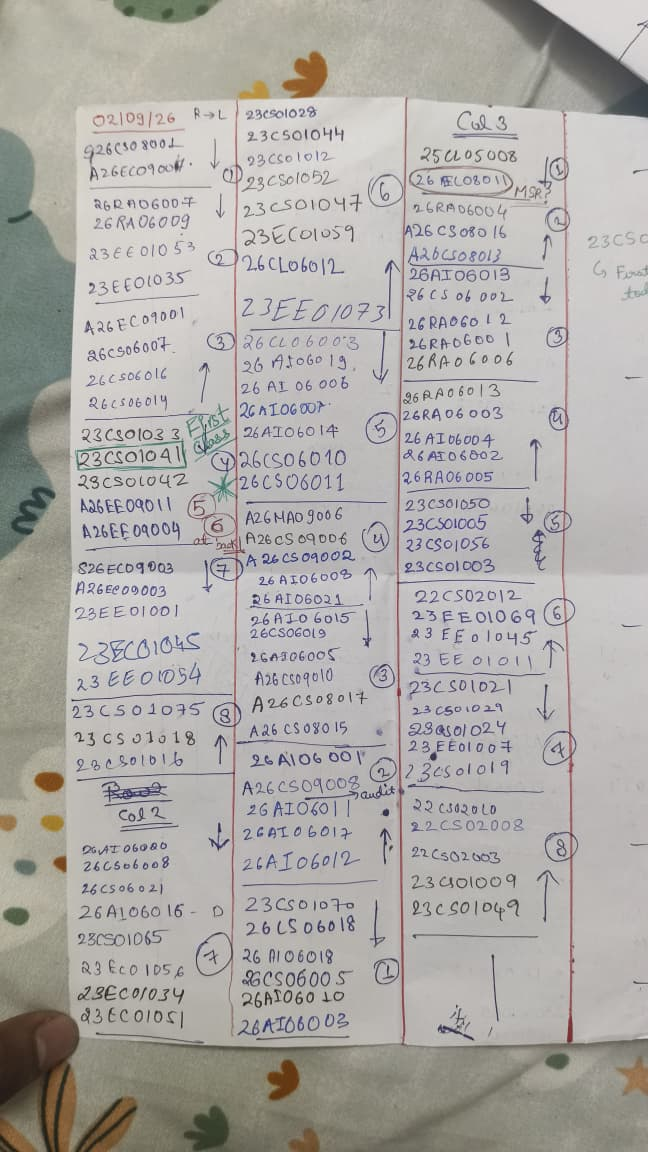

In [61]:
image = Image.open("2026-09-02 attendance sheet.jpeg")
image

In [62]:
print(image.size)

(648, 1152)


In [ ]:
image = Image.open("2026-09-02 attendance sheet.jpeg")
draw = ImageDraw.Draw(image)
for detection in detectionList:
    # print(detection.bounding_box)
    x1 = detection.bounding_box[0] * image.size[0] // 1000
    y1 = detection.bounding_box[1] * image.size[1] // 1000
    x2 = detection.bounding_box[2] * image.size[0] // 1000
    y2 = detection.bounding_box[3] * image.size[1] // 1000
    draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
    # break

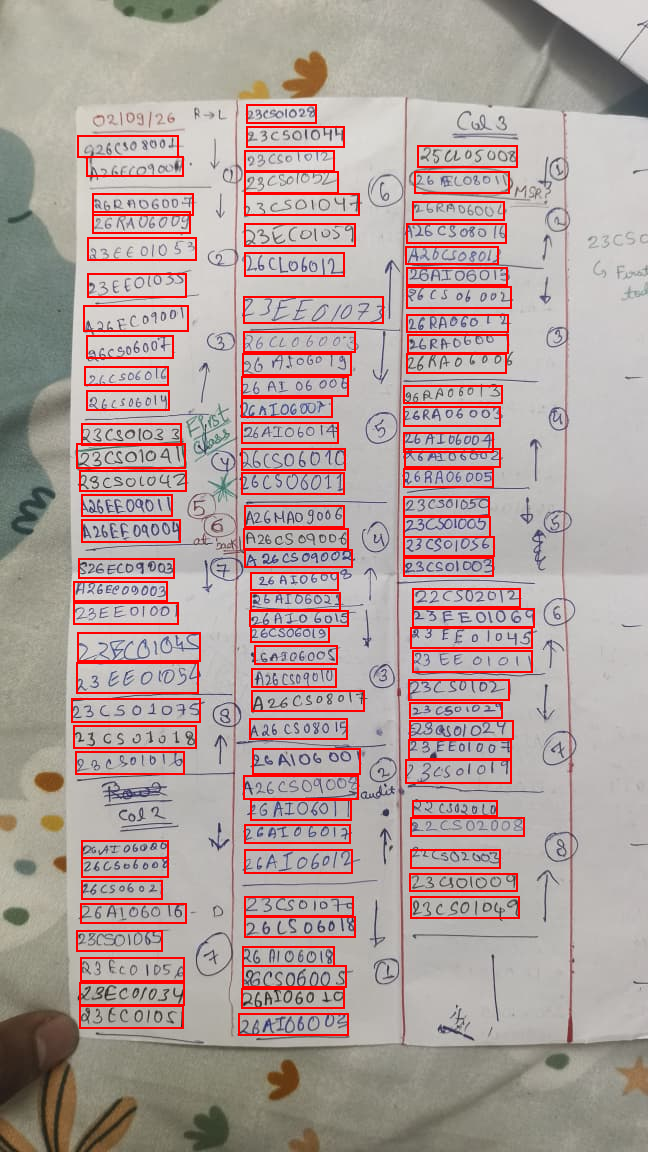

In [67]:
image

roll_text='23EE01035' any_comments='' bounding_box=[135, 237, 288, 258] confidence_score=10


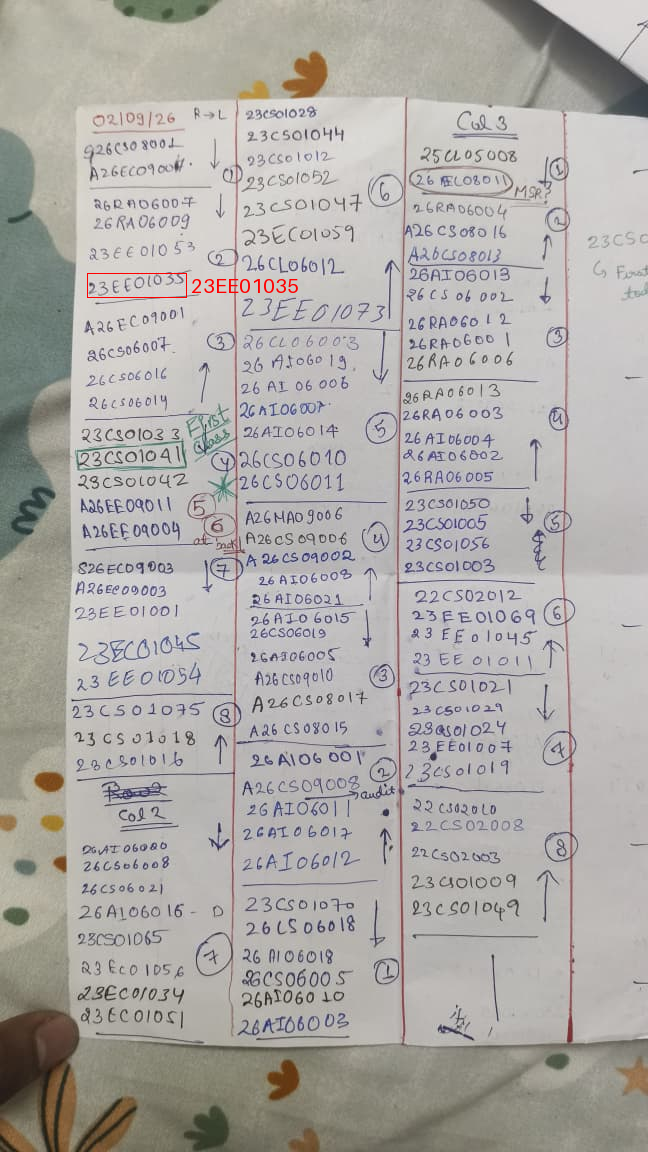

In [82]:
image = Image.open("2026-09-02 attendance sheet.jpeg")
draw = ImageDraw.Draw(image)
image_font = ImageFont.load_default(size=20)
for i, detection in enumerate(detectionList):
    if i == 5:
        print(detection)
        x1 = detection.bounding_box[0] * image.size[0] // 1000
        y1 = detection.bounding_box[1] * image.size[1] // 1000
        x2 = detection.bounding_box[2] * image.size[0] // 1000
        y2 = detection.bounding_box[3] * image.size[1] // 1000
        draw.rectangle([x1, y1, x2, y2], outline="red", width=1)
        draw.text((x2 + 5, y1), detection.roll_text, fill="red", font=image_font)
        break

image